# 03 · SAE features vs dense states vs surprisal

In [1]:
import sys, json, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir() and (p / "results").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import *

P = paths(ROOT)
FIG = P["figures"]
B, SEED = bootstrap_settings(ROOT)
set_style()
pd.set_option("display.precision", 3)

In [2]:
from sae_regression_diagnostics import paired_score, choose_inner_hooks

def load_run(c, k, l, r):
    f = P["regression"] / c / k / l / r
    return {"predictions": pd.read_csv(f / "predictions.csv"),
            "folds": json.loads((f / "folds.json").read_text())["folds"]}

layer_rows, selected, choices = [], {}, []
for c in CORPORA:
    for k in ["post", "prefix"]:
        for r in ["dense", "sae"]:
            runs = {l: load_run(c, k, l, r) for l in HOOK_ORDER if (P["regression"] / c / k / l / r / "folds.json").exists()}
            for l, run in runs.items():
                s = paired_score(run["predictions"], bootstrap=B, seed=SEED)
                layer_rows.append(dict(corpus=c, kind=k, rep=r, label=l, est=100 * s["delta_r2"],
                                       lo=100 * s["ci_low"], hi=100 * s["ci_high"], max_err=s["max_abs_error_log_ms"]))
            chosen, sel = choose_inner_hooks(runs)
            selected[(c, k, r)] = chosen
            choices += [dict(corpus=c, kind=k, rep=r, **x) for x in sel]
layers, choices = pd.DataFrame(layer_rows), pd.DataFrame(choices)

# Main result: hook and α chosen on training texts only

In [3]:
prim, rows = [], []
for c in CORPORA:
    for k in ["post", "prefix"]:
        sae, dense = selected[(c, k, "sae")], selected[(c, k, "dense")]
        assert sae.row_uid.tolist() == dense.row_uid.tolist()
        s, d = paired_score(sae, bootstrap=B, seed=SEED), paired_score(dense, bootstrap=B, seed=SEED)
        diff = paired_score(sae.assign(dense_prediction=dense.prediction.to_numpy()),
                            reference="dense_prediction", bootstrap=B, seed=SEED)
        for rep, sc in [("sae", s), ("dense", d)]:
            rows.append(dict(label=f"{CORPUS_LABELS[c].split(' ·')[0]} · {STATE_LABELS[k].lower()} · {REP_LABELS[rep]}",
                             corpus=c, rep=rep, est=100 * sc["delta_r2"], lo=100 * sc["ci_low"], hi=100 * sc["ci_high"]))
        prim.append({"Corpus": CORPUS_LABELS[c], "State": STATE_LABELS[k],
                     "SAE gain (pp)": ci_text(100 * s["delta_r2"], 100 * s["ci_low"], 100 * s["ci_high"]),
                     "Dense gain (pp)": ci_text(100 * d["delta_r2"], 100 * d["ci_low"], 100 * d["ci_high"]),
                     "SAE − dense (pp)": ci_text(100 * diff["delta_r2"], 100 * diff["ci_low"], 100 * diff["ci_high"]),
                     "Texts improved (SAE)": f"{s['texts_improved']}/{s['n_texts']}",
                     "_diff": (100 * diff["delta_r2"], 100 * diff["ci_low"], 100 * diff["ci_high"])})
prim = pd.DataFrame(prim)
display(prim.drop(columns="_diff"))

,Corpus,State,SAE gain (pp),Dense gain (pp),SAE − dense (pp),Texts improved (SAE)
0,Provo · FFD,After word,"+6.58 [+5.42, +7.78]","+2.80 [+1.90, +3.66]","+3.78 [+2.73, +4.88]",50/55
1,Provo · FFD,Before word,"+2.87 [+1.77, +3.98]","+1.07 [+0.56, +1.58]","+1.80 [+0.67, +2.88]",43/55
2,Natural Stories · SPR,After word,"+3.84 [+2.35, +5.18]","+6.23 [+3.38, +8.55]","-2.39 [-4.02, -0.45]",10/10
3,Natural Stories · SPR,Before word,"+0.82 [+0.19, +1.37]","+2.61 [+0.31, +4.61]","-1.79 [-3.49, +0.25]",7/10


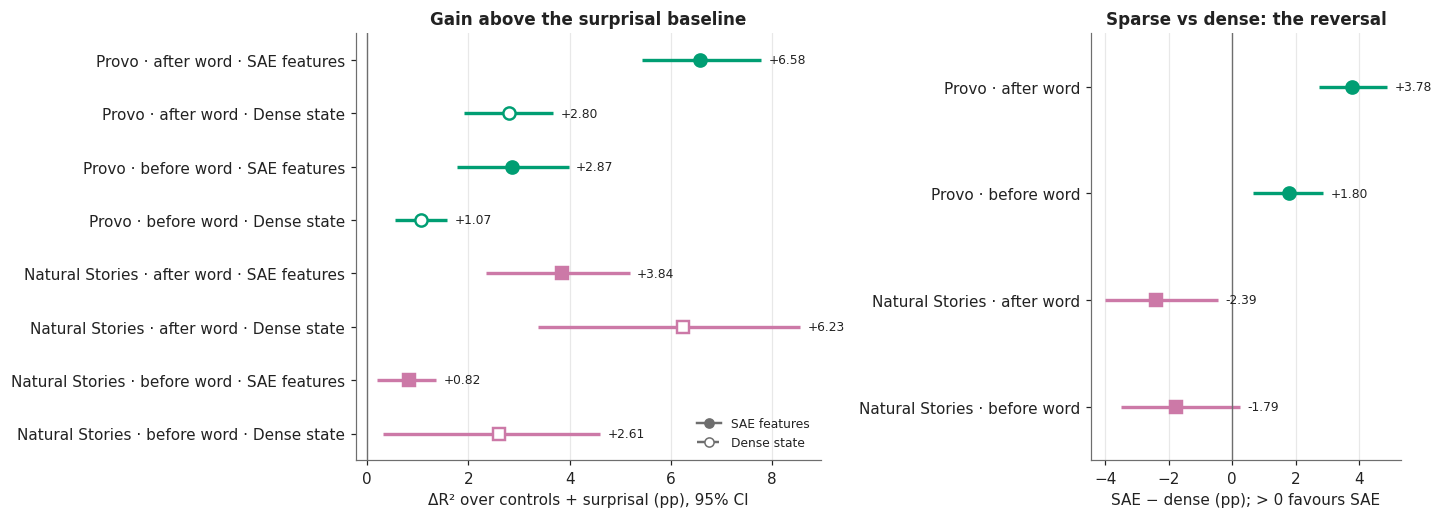

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), layout="constrained", gridspec_kw={"width_ratios": [1.5, 1]})
forest(axes[0], rows, xlabel="ΔR² over controls + surprisal (pp), 95% CI")
axes[0].set_title("Gain above the surprisal baseline")
rep_legend(axes[0], ("sae", "dense"), loc="lower right", fontsize=8)
drows = [dict(label=f"{r.Corpus.split(' ·')[0]} · {r.State.lower()}", corpus=c, rep="sae",
              est=r["_diff"][0], lo=r["_diff"][1], hi=r["_diff"][2])
         for (_, r), c in zip(prim.iterrows(), [c for c in CORPORA for _ in range(2)])]
forest(axes[1], drows, xlabel="SAE − dense (pp); > 0 favours SAE")
axes[1].set_title("Sparse vs dense: the reversal")
save_figure(fig, FIG, "03_main_result"); plt.show()

# Where in the network? (exploratory layer profile)

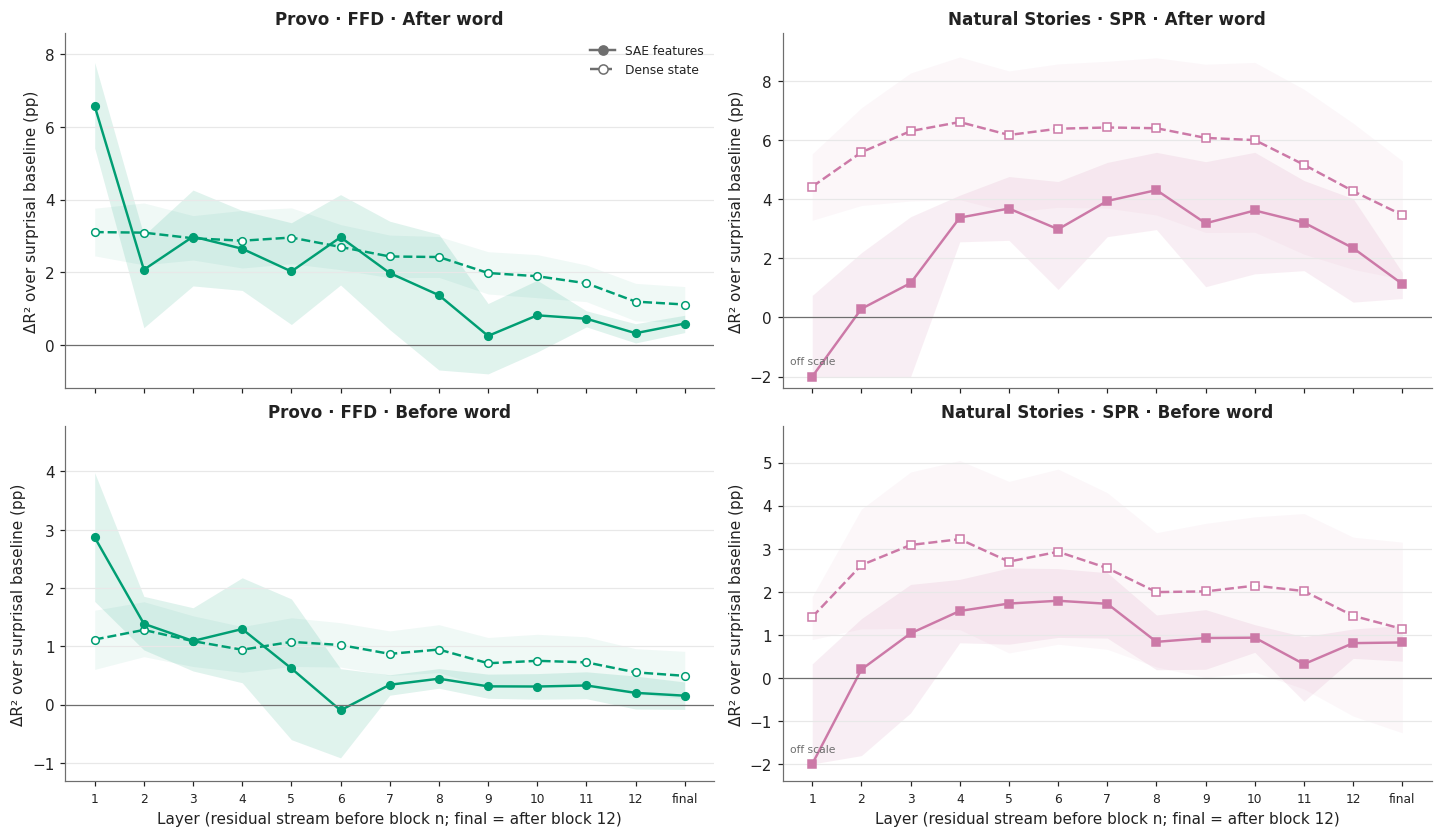

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), layout="constrained", sharex=True)
for j, c in enumerate(CORPORA):
    for i, k in enumerate(["post", "prefix"]):
        f = layers[(layers.corpus == c) & (layers.kind == k)]
        ymin = max(-2.0, f.lo.min())
        layer_profile(axes[i, j], f, c, clip=(-2.0, f.hi.max() + 0.5))
        axes[i, j].set_ylim(ymin - 0.4, f.hi.max() + 0.8)
        axes[i, j].set_title(f"{CORPUS_LABELS[c]} · {STATE_LABELS[k]}")
        axes[i, j].set_ylabel("ΔR² over surprisal baseline (pp)")
for ax in axes[0]:
    ax.set_xlabel("")
rep_legend(axes[0, 0], ("sae", "dense"), corpus="provo", fontsize=8)
save_figure(fig, FIG, "03_layer_profile"); plt.show()

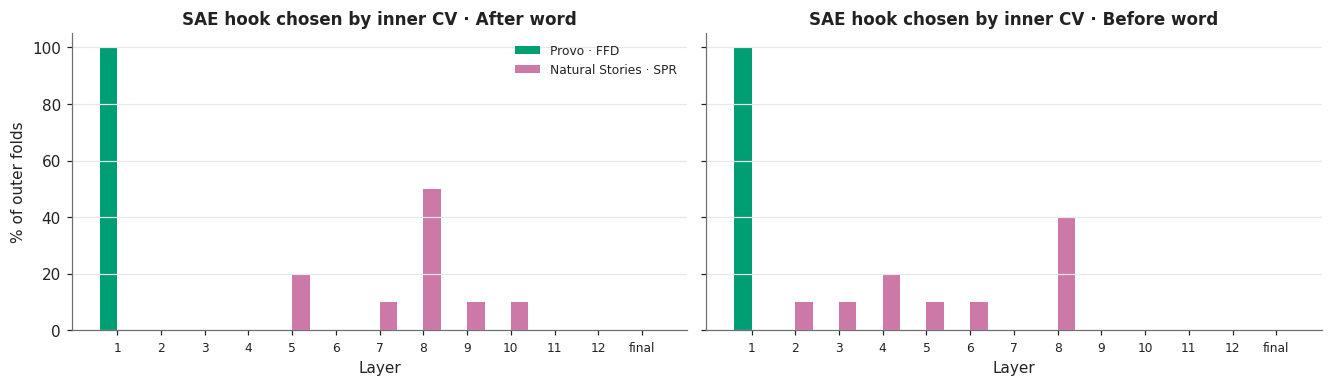

In [6]:
sel = (choices[choices.rep == "sae"].groupby(["corpus", "kind", "label"]).size()
       .rename("folds").reset_index())
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), layout="constrained", sharey=True)
w = 0.4
for ax, k in zip(axes, ["post", "prefix"]):
    for o, c in zip([-w / 2, w / 2], CORPORA):
        g = sel[(sel.corpus == c) & (sel.kind == k)].set_index("label").reindex(HOOK_ORDER).folds.fillna(0)
        n = choices[(choices.corpus == c) & (choices.kind == k) & (choices.rep == "sae")].fold.nunique()
        ax.bar(np.arange(13) + o, 100 * g / n, w, color=CORPUS_COLORS[c], label=CORPUS_LABELS[c])
    ax.set_xticks(range(13), HOOK_TICKS, fontsize=8); ax.set_title(f"SAE hook chosen by inner CV · {STATE_LABELS[k]}")
    ax.set_xlabel("Layer"); ax.grid(axis="y", color=GRID)
axes[0].set_ylabel("% of outer folds"); axes[0].legend(fontsize=8)
save_figure(fig, FIG, "03_hook_selection"); plt.show()

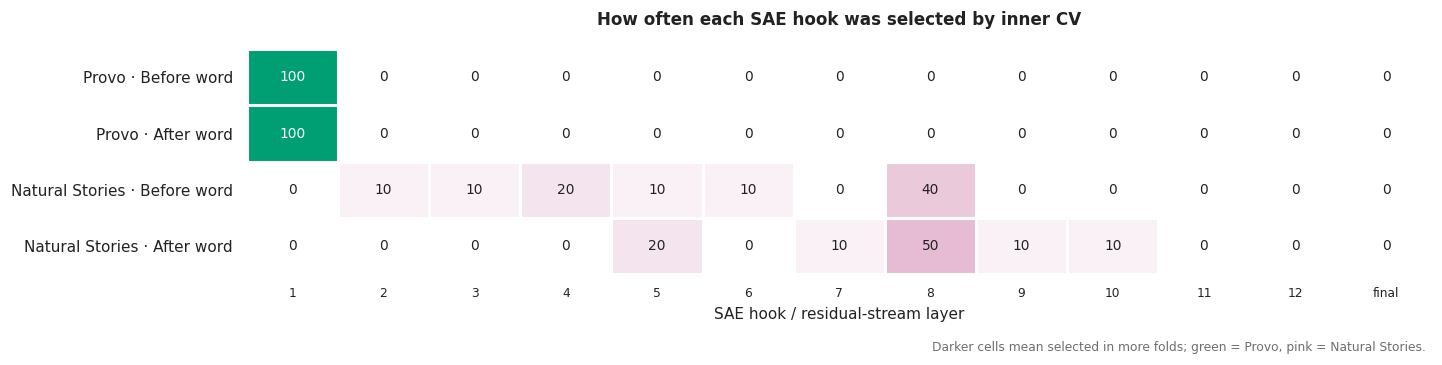

,L01,L02,L03,L04,L05,L06,L07,L08,L09,L10,L11,L12,final_resid_post
Dataset/state,,,,,,,,,,,,,
Provo · Before word,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Provo · After word,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Natural Stories · Before word,0.0,10.0,10.0,20.0,10.0,10.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0
Natural Stories · After word,0.0,0.0,0.0,0.0,20.0,0.0,10.0,50.0,10.0,10.0,0.0,0.0,0.0


In [7]:
selection = pd.read_csv(ROOT / "reports/sae_prediction/hook_selection.csv")
model_cmp = pd.read_csv(ROOT / "reports/sae_prediction/model_comparison.csv")

rows = []
row_corpora = []
for corpus in CORPORA:
    for kind in ["prefix", "post"]:
        total = int(model_cmp[(model_cmp.corpus == corpus) & (model_cmp.kind == kind) &
                              (model_cmp.representation == "sae") &
                              (model_cmp.label == "inner_selected")]["n_texts"].iloc[0])
        sub = selection[(selection.corpus == corpus) & (selection.kind == kind) &
                        (selection.representation == "sae")]
        row = {label: 0.0 for label in HOOK_ORDER}
        for r in sub.itertuples():
            row[r.label] = 100 * r.fold_count / total
        row["Dataset/state"] = f"{CORPUS_LABELS[corpus].split(' ·')[0]} · {STATE_LABELS[kind]}"
        rows.append(row)
        row_corpora.append(corpus)

sel_pct = pd.DataFrame(rows).set_index("Dataset/state")[HOOK_ORDER]
values = sel_pct.to_numpy(float)

# Corpus-colored heatmap: each row fades from white to that corpus color.
rgba = np.ones((*values.shape, 4))
for i, corpus in enumerate(row_corpora):
    base = np.array(plt.matplotlib.colors.to_rgb(CORPUS_COLORS[corpus]))
    alpha = np.clip(values[i] / 100, 0, 1)[:, None]
    rgba[i, :, :3] = (1 - alpha) * np.ones(3) + alpha * base
    rgba[i, :, 3] = 1

fig, ax = plt.subplots(figsize=(13, 3.2), layout="constrained")
ax.imshow(rgba, aspect="auto")
ax.set_xticks(np.arange(len(HOOK_ORDER)), HOOK_TICKS, fontsize=8)
ax.set_yticks(np.arange(len(sel_pct)), sel_pct.index)
ax.tick_params(length=0, pad=9)
for (i, j), value in np.ndenumerate(values):
    color = "white" if value >= 65 else INK
    ax.text(j, i, f"{value:.0f}", ha="center", va="center", fontsize=9, color=color)
ax.set_xticks(np.arange(-.5, len(HOOK_ORDER), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(sel_pct), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("How often each SAE hook was selected by inner CV", pad=16)
ax.set_xlabel("SAE hook / residual-stream layer")
ax.text(0.995, -0.30, "Darker cells mean selected in more folds; green = Provo, pink = Natural Stories.",
        transform=ax.transAxes, ha="right", va="top", fontsize=8, color=MUTED)
save_figure(fig, FIG, "03_sae_hook_selection_heatmap")
plt.show()

display(sel_pct.round(1))

In [8]:
# f = P["scaling"] / "comparison.csv"
# if f.exists():
#     sc = pd.read_csv(f)
#     fig, ax = plt.subplots(figsize=(7, 3), layout="constrained")
#     for i, r in enumerate(sc.itertuples()):
#         ax.plot([r.original_max_abs_error, r.floor_max_abs_error], [i, i], color=LIGHT, lw=2, zorder=1)
#         ax.plot(r.original_max_abs_error, i, marker=CORPUS_MARKERS[r.corpus], color=CORPUS_COLORS[r.corpus], mfc="white", ms=8, ls="")
#         ax.plot(r.floor_max_abs_error, i, marker=CORPUS_MARKERS[r.corpus], color=CORPUS_COLORS[r.corpus], ms=8, ls="")
#     ax.set_yticks(range(len(sc)), [f"{CORPUS_LABELS[r.corpus].split(' ·')[0]} · {STATE_LABELS[r.state].lower()}" for r in sc.itertuples()])
#     ax.set_xscale("log"); ax.set_xlabel("Worst absolute error (log-ms); open = original, filled = SD floor")
#     ax.set_title("L01: a training-SD floor removes the extreme errors"); ax.grid(axis="x", color=GRID)
#     save_figure(fig, FIG, "03_l01_scaling"); plt.show()
#     display(sc[["corpus", "state", "original_gain_pp", "floor_gain_pp", "floor_ci_low_pp", "floor_ci_high_pp",
#                 "original_max_abs_error", "floor_max_abs_error"]].round(2))